# Subspace Estimation and MUSIC in Multi-Target Scenario
This notebook will introduce you the *MUltiple SIgnal Classification* (MUSIC) algorithm, a very common and simple algorithm used in the DoA estimation problem, along with discussing the covariance matrix in more detail. Meanwhile, we will also implement different data models. 

In [ ]:
# Importing modules
import numpy as np; 
import matplotlib.pyplot as plt; 

## Data Model

* Antenna position matrix $\mathbf{P} \in \mathbb{R}^{3 \times N}$ holds the values for the position of the $n^{th}$ antenna element with respect to the origin point in meters.

$$
\mathbf{p}_{n} = [p_{n,x} \hat{\mathbf{x}}, p_{n,y} \hat{\mathbf{y}}, p_{n,z} \hat{\mathbf{z}}]^{T} \in \mathbb{R}^{3 \times 1}
\\
\mathbf{P} = [\mathbf{p}_{1}, ..., \mathbf{p}_{N}] \in \mathbb{R}^{3 \times N}
$$

* Target angle vector $\mathbf{\omega}_{k} \in \mathbb{R}^{3 \times 1}$ is the 3D Cartesian coordinate expression of the $k^{th}$ target's azimuth ($\phi_k$) and elevation ($\theta_k$) angles.

$$
\mathbf{\omega}_{k} = [sin(\theta_k)cos(\phi_k), sin(\theta_k)sin(\phi_k), cos(\phi_k)]^T \in \mathbb{R}^{3 \times 1}
$$

* The derivative of the target angle vector with respect to the elevation angle $\frac{\partial \mathbf{\omega}_{k}}{\partial \theta_{k}} \in \mathbb{R}^{3 \times 1}$ is used to calculate the derivate of the steering vector.

$$
\frac{\partial \mathbf{\omega}_{k}}{\partial \theta_{k}} = [cos(\theta_k)cos(\phi_k), cos(\theta_k)sin(\phi_k), -sin(\phi_k)]^T \in \mathbb{R}^{3 \times 1}
$$

In [ ]:
# Defining methods
hermitian = lambda array: np.conj(array).T


def steering_vector(
    sensor_pos: np.ndarray,
    ang_elev: float,
    ang_azim: float,
    wavelen: float
    ) -> np.ndarray:
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]);
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 

def d_steering_vector(
    sensor_pos: np.ndarray,
    ang_elev: float,
    ang_azim: float,
    wavelen: float
    ) -> np.ndarray:
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelen);
  d_omega = np.array([[np.cos(ang_elev)*np.cos(ang_azim)],
                      [np.cos(ang_elev)*np.sin(ang_azim)],
                      [-np.sin(ang_elev)]]);
  return -1j*2*np.pi/wavelen * a * sensor_pos.T@d_omega; 


def generate_pos_1d_ula(
    N: int,
    d: float,
    axis=(1.,0.,0.),
    x_init=(0.,0.,0.)
    ) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3.""")
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def generate_random_targets(ang_min: float, ang_max: float, ang_dist: float, K: int) -> np.ndarray:
  """
  Generate K uniformly random target angles between ang_min and ang_max with a minimum separation angle of ang_dist.

  --Inputs--
  ang_min: Minimum angle in degrees. Type of float.
  ang_max: Maximum angle in degrees. Type of float.
  ang_dist: Minimum separation angle in degrees. Type of float.
  K: Number of target angles. Type of int.

  --Output--
  angs: K uniformly random angles. Type of np.ndarray of size (K,) and dtype of np.float64.
  """
  while True:
    angs = np.random.uniform(ang_min, ang_max, K, dtype=np.float64); 
    angs_sort = np.sort(angs); 
    for i in range(K-1):  # break for if is not valid
      is_valid = np.abs(angs_sort[i+1] - angs_sort[i]) >= ang_dist; 
      if not is_valid:
        break; 
    if is_valid: break;   # break while if is valid
  return angs; 

## Current Benchmarks: DAS and MVDR

Since we already have the implementation of DAS (Bartlett) and MVDR (Capon) beamforming algorithms, we can wrap them in a method and call them in comparison with MUSIC. As we move further, we will continue including comparing the performance of different algorithms.

Confused with the names? Where is DAS? What is Capon? Go back to the previous notebook and take your refresher!

In [ ]:
def doa_est_bartlett(
    theta_scan: np.ndarray,
    sensor_pos: np.ndarray,
    R_xx: np.ndarray,
    wl: float) -> np.ndarray:
  """
  Generates the Bartlett power pseudospectrum for a given scan angle range. 

  --Inputs--
  theta_scan: Elevation angle scan array in degrees. Type of np.ndarray of size (N,1) and dtype np.float64.
  sensor_pos: Antenna array sensor positions in 3D Cartesian coordinates. Type of np.ndarray of size (3,N) and dtype np.float64.
  R_xx: Signal covariance matrix. Type of np.ndarray of size (N,N) and dtype np.complex128.
  wl: Signal of interest wavelength. Type of float. 

  --Output--
  P_bartlett: Bartlett pseudospectrum. Type of np.ndarray of size (N,1) and dtype np.float64.
  """
  P_bartlett = np.zeros(len(theta_scan), dtype=np.complex128); 

  for i, theta in enumerate(theta_scan):
    bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    P_bartlett[i] = np.squeeze(hermitian(bartlett) @ R_xx @ bartlett); 

  return P_bartlett; 


def doa_est_capon(
    theta_scan: np.ndarray,
    sensor_pos: np.ndarray,
    R_xx: np.ndarray,
    wl: float) -> np.ndarray:
  """
  Generates the Capon (MVDR) power pseudospectrum for a given scan angle range. 

  --Inputs--
  theta_scan: Elevation angle scan array in degrees. Type of np.ndarray of size (N,1) and dtype np.float64.
  sensor_pos: Antenna array sensor positions in 3D Cartesian coordinates. Type of np.ndarray of size (3,N) and dtype np.float64.
  R_xx: Signal covariance matrix. Type of np.ndarray of size (N,N) and dtype np.complex128.
  wl: Signal of interest wavelength. Type of float. 

  --Output--
  P_capon: Capon pseudospectrum. Type of np.ndarray of size (N,1) and dtype np.float64.
  """
  Rxx_inv = np.linalg.inv(R_xx); 
  P_capon = np.zeros(len(theta_scan), dtype=np.complex128); 

  for i, theta in enumerate(theta_scan):
    bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    capon = (Rxx_inv @ bartlett) / (hermitian(bartlett) @ Rxx_inv @ bartlett); 
    P_capon[i] = np.squeeze(hermitian(capon) @ R_xx @ capon); 

  return P_capon; 

## Parameters
* $c$: Speed of light. In this example, assumed to be rounded to $30*10^8\text{ m/s}$.
* $f$: Frequency of the target signals in Herz. For this example, we will use $5\text{ GHz}$
* $\lambda$: Wavelength of the target signals in meters. It is calculated by the classical formula: $\lambda = \frac{c}{f}$, which gives $6\text{ cm}$ in our case.

Next step is to determine the ULA parameters.

* $N$: # of antenna elements. We can choose this value as $16$.
* $T$: # of snapshots. MUSIC is an algorithm that benefits high number of snapshots in order to average the sample covariance matrix to the true one as much as possible, therefore we went with a rather big number of $4000$. You can always change and see its effect on the estimation after giving this value a try first.
* $K$: # of targets. For an easy case, let's keep the number of targets at $3$.

In [ ]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f = 5*1e9;      # Narrowband signal frequency (Hz)
wl = c/f;       # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 4000;       # Number of snapshots
K = 3;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)
snr_db = 10.0;  # Signal-to-Noise Ratio (dB)

ang_azim = 90;  # Azimuth angle (deg)
ang_min = -90;  # Minimum elevation angle (deg)
ang_max = 90;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 0.1   # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position
theta_scan = np.arange(-90,90+ang_res,ang_res);                         # Angle scan
true_angles = generate_random_targets(ang_min, ang_max, ang_dist, K);   # Target elevation angles

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.3f}°"); 

## Signal Generation
We will use the narrowband far-field model with Rayleigh fading to make our life as easy as possible (refer to the previous notebook if none of these terms makes sense to you).

In [ ]:
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix

# Data Generation
S = (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); # Target Signals: Uncorrelated Gaussian (variance = 1.0)

# Noise: Spatially white complex Gaussian noise
noise_var = 10**(-snr_db/10);
Noise = np.sqrt(noise_var) * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2);

# Received Signal at the Array
X = A @ S + Noise;

## Calculating the Cramer-Rao Lower Bound (CRLB)

We will mention the Cramer-Rao Lower Bound (CRLB) in the coming notebooks, however for now you can understand it as the absolute lower bound of error we can reach regardless of any estimation algorithm we use. It has its roots in the field of information theory, if you are impatient you can look at some resources in the links below.

On YouTube: [The Fisher Information](https://www.youtube.com/watch?v=pneluWj-U-o) by Mutual Information gives the essential information for understanding the Fisher Information Matrix (FIM), which is used to construct the Cramer-Rao Lower Bound.

[Maximum Likelihood - Cramer Rao Lower Bound Intuition](https://www.youtube.com/watch?v=i0JiSddCXMM) by Ben Lambert gets into the intuition behind the CRLB.

The CRLB formula we are using here is based on the paper [here](https://ieeexplore.ieee.org/abstract/document/17564)

In [ ]:
def calculate_crb(
    sensor_pos: np.ndarray, 
    N: int, 
    T: int, 
    angs_elev: np.ndarray, 
    snr_db: float, 
    S_db: list) -> np.ndarray:
  """
  Calculates the stochastic Cramer-Rao Lower Bound (CRLB) for a given sensor
  array and number of targets.
  """
  noise_pow = 10**(-snr_db/10); 
  sig_pow = [10**(s_db)/10 for s_db in S_db]; 
  R_ss = np.diag(np.array(sig_pow)); 

  K = angs_elev.shape[0]; 

  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A_mat = np.zeros((N, K), dtype=complex); 
  D_mat = np.zeros((N, K), dtype=complex); 

  for i, theta in enumerate(angs_elev):
    A_mat[:,i] = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0];
    D_mat[:,i] = d_steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0];

  Rxx_true = A_mat@R_ss@A_mat.conj().T + noise_pow*np.eye(N);
  Rxx_inv = np.linalg.inv(Rxx_true);

  P_A_perp = np.eye(N) - A_mat@np.linalg.inv(A_mat.conj().T@A_mat)@A_mat.conj().T; # Projection matrix onto the noise subspace

  # The Fisher Information Matrix components
  term1 = D_mat.conj().T @ P_A_perp @ D_mat; 
  term2 = (R_ss @ A_mat.conj().T @ Rxx_inv @ A_mat @ R_ss).T; 

  FIM = (2*T/noise_pow) * np.real(term1 * term2);

  return np.linalg.inv(FIM);


In [ ]:
## Cramer-Rao Bound
CRB_mat = calculate_crb(sensor_pos, N, T, true_angles, snr_db, S_db); 
CRB_var = np.diag(CRB_mat);       # The diagonal elements are the minimum variances for target 1 and target 2
CRB_rmse = np.sqrt(CRB_var);      # Convert variance (deg^2) to Standard Deviation / RMSE (deg)

## The MUSIC Algorithm

Paper link for the MUSIC algorithm is [here](https://ieeexplore.ieee.org/abstract/document/1143830).

In [ ]:
# The MUSIC Algorithm
Rxx_samp = (X @ X.conj().T)/T;        # Sample (estimated) covariance
_, eigenvectors = np.linalg.eigh(Rxx_samp); 
Un = eigenvectors[:, :-K];            # Noise space

P_music = np.zeros(len(theta_scan)); 

# Creating the MUSIC pseudospectrum
for i, theta in enumerate(theta_scan):
    a_theta = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    denominator = np.abs(a_theta.conj().T @ Un @ Un.conj().T @ a_theta); 
    P_music[i] = 1 / np.squeeze(denominator); 

P_music_dB = 10 * np.log10(P_music / np.max(P_music)); 

In [ ]:
# Running the compared algorithms (DAS and MVDR)
P_bartlett = doa_est_bartlett(theta_scan, sensor_pos, Rxx_samp, wl); 
P_bartlett_dB = 10*np.log10(np.abs(np.multiply(P_bartlett/np.amax(P_bartlett), np.conjugate(P_bartlett/np.amax(P_bartlett))))); 

P_capon = doa_est_capon(theta_scan, sensor_pos, Rxx_samp, wl); 
P_capon_dB = 10*np.log10(np.abs(np.multiply(P_capon/np.amax(P_capon), np.conjugate(P_capon/np.amax(P_capon))))); 

In [ ]:
# Printing the results
print("\nTheoretical Performance Limits (Stochastic CRB)");
for i in range(K):
    print(f"Target {i+1} ({true_angles[i]:.2f}°): Minimum RMSE = {CRB_rmse[i]:.5f}");


Theoretical Performance Limits (Stochastic CRB)
Target 1 (-34.06°): Minimum RMSE = 0.00094
Target 2 (31.21°): Minimum RMSE = 0.00092
Target 3 (-13.91°): Minimum RMSE = 0.00081


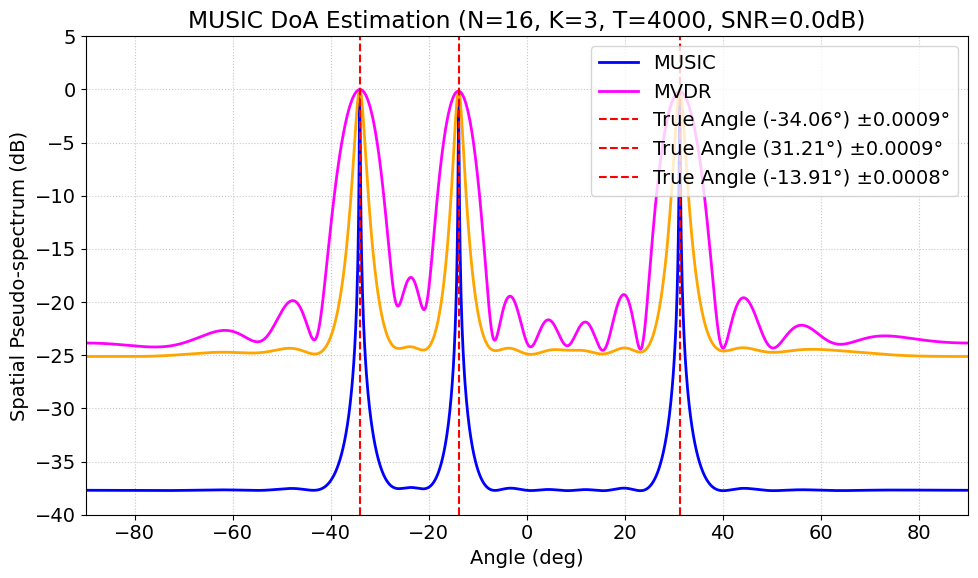

In [ ]:
# Visualization
plt.rcParams.update({'font.size': 14});

plt.figure(figsize=(10, 6));
plt.plot(theta_scan, P_music_dB, linewidth=2, color='blue', label='MUSIC');
plt.plot(theta_scan, P_capon_dB, linewidth=2, color='orange', label='MVDR');
plt.plot(theta_scan, P_bartlett_dB, linewidth=2, color='magenta', label='MVDR');

for i, angle in enumerate(true_angles):
    plt.axvline(x=angle, color='red', linestyle='--',
                label=f'True Angle ({angle:.2f}°) ±{CRB_rmse[i]:.4f}°');

plt.title(f'MUSIC DoA Estimation (N={N}, K={K}, T={T}, SNR={snr_db}dB)');
plt.xlabel('Angle (deg)');
plt.ylabel('Spatial Pseudo-spectrum (dB)');
plt.xlim([ang_min, ang_max]);
plt.ylim([-40, 5]);
plt.grid(True, linestyle=':', alpha=0.7);

handles, labels = plt.gca().get_legend_handles_labels();
by_label = dict(zip(labels, handles));
plt.legend(by_label.values(), by_label.keys());

plt.tight_layout();
plt.show();